In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 4

In [3]:
f(4)

36

In [4]:
xs= np.arange(-5, 5, 0.25)

In [5]:
ys = f(xs)

In [6]:
ys

array([99.    , 90.6875, 82.75  , 75.1875, 68.    , 61.1875, 54.75  ,
       48.6875, 43.    , 37.6875, 32.75  , 28.1875, 24.    , 20.1875,
       16.75  , 13.6875, 11.    ,  8.6875,  6.75  ,  5.1875,  4.    ,
        3.1875,  2.75  ,  2.6875,  3.    ,  3.6875,  4.75  ,  6.1875,
        8.    , 10.1875, 12.75  , 15.6875, 19.    , 22.6875, 26.75  ,
       31.1875, 36.    , 41.1875, 46.75  , 52.6875])

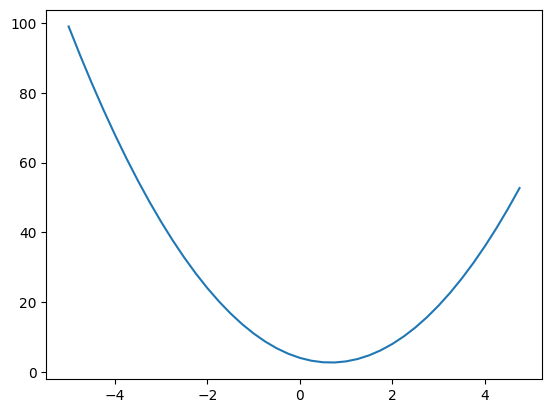

In [7]:
plt.plot(xs,ys)

In [8]:
h = 0.001
x = 3.0
print(f(x))
print(f(x + h))
print((f(x + h) - f(x)))
print((f(x + h) - f(x)) / h)

19.0
19.014003000000002
0.01400300000000243
14.00300000000243


In [9]:
h = 0.001
x = -3.0
print(f(x))
print(f(x + h))
print((f(x + h) - f(x)))
print((f(x + h) - f(x)) / h)

43.0
42.978003
-0.021996999999998934
-21.996999999998934


Above we tried to find the derivative of the function manually and we tested it on the derivative formula. Now we will take a look at a more complex function.

In [10]:
a = 2.0
b = -4.9
c = 9.3
d = a**b + c*a - a*b

In [11]:
print(d)

28.43349292070426


Now we will take a look at the derivatives of d with respect to a,b and c.

In [12]:
h = 0.001

a = 2.0
b = -4.9
c = 9.3

In [13]:
d1 = a**b + c*a - a*b

In [14]:
a += h
d2 = a**b + c*a - a*b

In [15]:
print('d1 = ', d1)
print('d2 = ', d2)

d1 =  28.43349292070426
d2 =  28.447610983944525


In [16]:
print("slope = ", (d2-d1)/h)

slope =  14.118063240264433


In [17]:
h = 0.001

a = 2.0
b = -4.9
c = 9.3

In [18]:
b += h
d3 = a**b + c*a - a*b
print('d1 = ', d1)
print('d3 = ', d3)  
print("slope = ", (d3-d1)/h)

d1 =  28.43349292070426
d3 =  28.431516144275562
slope =  -1.9767764286982015


In [19]:
h = 0.001

a = 2.0
b = -4.9
c = 9.3

In [20]:
c += h
d4 = a**b + c*a - a*b
print('d1 = ', d1)
print('d4 = ', d3)  
print("slope = ", (d4-d1)/h)

d1 =  28.43349292070426
d4 =  28.431516144275562
slope =  1.9999999999988916


### Building out the "Value" function present on the readme page of micrograd repository.

In [21]:
class Value:
    def __init__(self, data, _children =(), _op = '' ):
        self.data = data
        self.grad = 0
        self._prev = set(_children)
        self._op = _op
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self,), 'tanh')
        return out

In [22]:
a = Value(3.0)
print(a)

Value(data=3.0)


In [23]:
b = Value(4.0)

In [24]:
a + b 

Value(data=7.0)

In [25]:
a * b

Value(data=12.0)

In [26]:
c = Value(-9.0)

In [27]:
d = a * b + c * b

In [28]:
d

Value(data=-24.0)

In [29]:
d._prev

{Value(data=-36.0), Value(data=12.0)}

In [30]:
d._op

'+'

In [31]:
L = d * a + b + c * d

In [32]:
L

Value(data=148.0)

In [33]:
def lol():

    h = 0.001

    a = Value(2.0)
    b = Value(-3.0)
    c = Value(10.0)
    e = a*b
    d = e + c
    f = Value(-2.0)
    L = d * f
    L1 = L.data

    a = Value(2.0 + h)
    b = Value(-3.0)
    c = Value(10.0)
    e = a*b
    d = e + c
    f = Value(-2.0)
    L = d * f
    L2 = L.data

    print((L2 - L1) / h)
lol()

6.000000000000227


In [34]:
L.grad = 1 

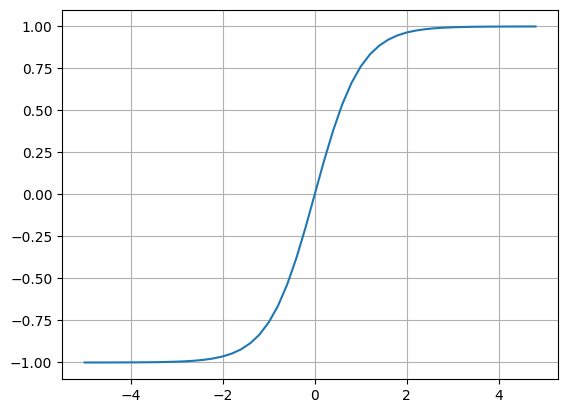

In [35]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))) 
plt.grid()

### Creating a neuron and calculating its backpropagation

In [36]:
# Inputs x1, x2

x1 = Value(2.0)
x2 = Value(0)

# Weights w1, w2

w1 = Value(-3.0)
w2 = Value(1.0)

# Bias of the neuron

b = Value(6.8813735870195432)

x1w1 = x1 * w1
x2w2 = x2 * w2
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b

# Output
o = n.tanh()


In [37]:
o

Value(data=0.7071067811865476)

In [38]:
o.grad = 1.0

In [39]:
o.data

0.7071067811865476

O = tanh(n) 

do / dn = 1 - tanh^2(n)

do / dn = 1 - o^2

In [40]:
1 - o.data**2

0.4999999999999999

In [41]:
n.grad = 0.5

In [42]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

### As this is very manual process, will now modify our value class to handle this via code.

In [45]:
class Value:
    def __init__(self, data, _children =(), _op = '' ):
        self.data = data
        self.grad = 0
        self._prev = set(_children)
        self._backward = lambda : None
        self._op = _op
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad = 1 * out.grad
            other.grad = 1 * out.grad
            
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        return out
    

In [47]:
# Inputs x1, x2

x1 = Value(2.0)
x2 = Value(0)

# Weights w1, w2

w1 = Value(-3.0)
w2 = Value(1.0)

# Bias of the neuron

b = Value(6.8813735870195432)

x1w1 = x1 * w1
x2w2 = x2 * w2
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b

# Output
o = n.tanh()


In [48]:
o.grad = 1.0
o._backward()

In [49]:
n._backward()

In [51]:
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
x1._backward()
w1._backward()
x2._backward()
w2._backward()

### Now we have calculated all the gradients and back prop via code but we have manually called the _backward() function and now we will try to solve this case as well.